In [1]:
#import rich
#from rich import inspect, pretty
#from rich import print
#pretty.install()
#%load_ext rich

import multiprocessing as mp
from collections import defaultdict
from functools import partial

import sklearn

import math
import os
import csv
import time
import json
import re
import warnings
import datetime
warnings.filterwarnings('ignore')
import random
import pickle

import numpy as np
import pandas as pd
pd.options.display.max_columns = None
pd.options.display.max_rows = 100

from scipy import stats

from collections import defaultdict, Counter
import itertools

from tqdm.auto import tqdm

tqdm.pandas() # df.progress_apply()



import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from string import printable

from matplotlib.dates import DateFormatter
from matplotlib.gridspec import GridSpec

#import gc
#gc.collect()

from wordcloud import WordCloud

import plotly.graph_objects as go
import networkx as nx

import cugraph
import cudf
#import pyintergraph as pig
random_seed = 42  # Fixed seed for reproducibility

import requests
import datetime
import ast

%config IPCompleter.use_jedi = False

## Time Array

In [24]:
time_array = pd.read_csv("cmake-build-debug/time_array.txt")

In [25]:
time_array = time_array.rename(columns ={"0.000" : "Time"})

In [26]:
time_array["Shifted_time"] = time_array["Time"] - min(time_array["Time"])

In [27]:
sorted_times =  sorted(time_array["Shifted_time"])

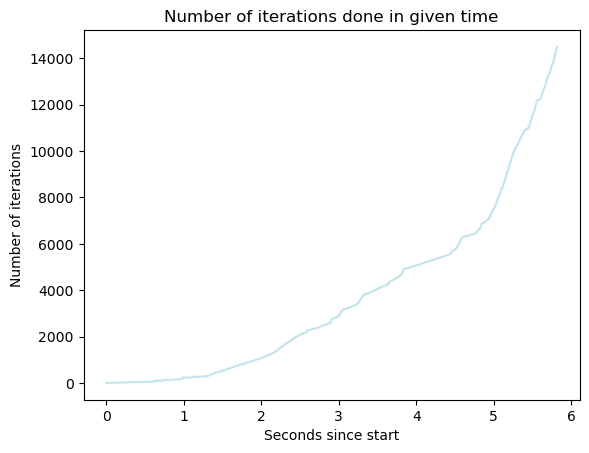

In [23]:
plt.plot(sorted_times, range(len(sorted_times)), color = "lightblue", alpha = 0.7)

plt.title("Number of iterations done in given time")

plt.xlabel("Seconds since start")
plt.ylabel("Number of iterations")

plt.savefig("rate_limit_going_up.png")
plt.show()

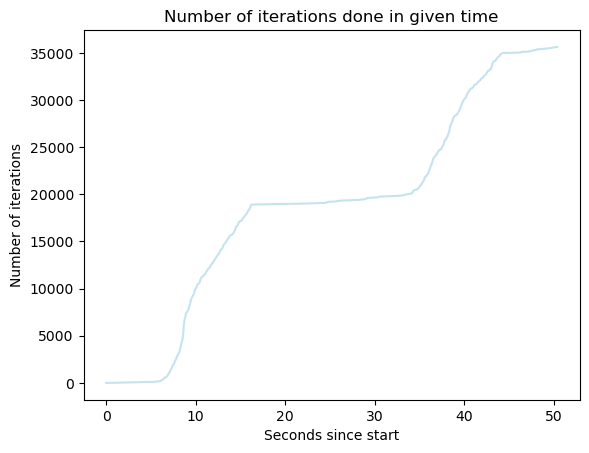

In [28]:
plt.plot(sorted_times, range(len(sorted_times)), color = "lightblue", alpha = 0.7)

plt.title("Number of iterations done in given time")

plt.xlabel("Seconds since start")
plt.ylabel("Number of iterations")

plt.savefig("rate_limit_stagnated.png")
plt.show()

## Parent Graphs

This was done by using LLMs

In [54]:
import re

def clean_csv_urls(input_file, output_file):
    # Regex Pattern Explanation:
    # Group 1 (.*?): Matches the 'site' URL
    # Group 2 (\d+): Matches the 'distance' (one or more digits)
    # Group 3 (http.*|): Matches the 'parent' URL (starts with 'http' or is completely empty)
    # By strictly requiring the 3rd group to start with 'http', we prevent the script from 
    # accidentally splitting on a number that is part of a URL (e.g. /page,3,something)
    pattern = re.compile(r'^(.*?),(\d+),(http.*|)$', re.IGNORECASE)
    
    # Fallback pattern just in case a parent URL isn't absolute (splits at the LAST number instead)
    fallback_pattern = re.compile(r'^(.*),(\d+),(.*)$')

    with open(input_file, 'r', encoding='utf-8') as infile, \
         open(output_file, 'w', encoding='utf-8') as outfile:
        
        # 1. Read and write the header unmodified
        header = infile.readline()
        outfile.write(header)
        
        # 2. Process every line one by one
        for line in infile:
            line = line.strip()
            if not line:
                continue
            
            # Try the strict pattern first
            match = pattern.match(line)
            if not match:
                # If that fails, fallback to splitting at the last number surrounded by commas
                match = fallback_pattern.match(line)
            
            if match:
                # Group 1 is the site. Replace its commas with nothing.
                site = match.group(1).replace(',', '')
                
                # Group 2 is the distance. Keep it as-is.
                distance = match.group(2)
                
                # Group 3 is the parent. Replace its commas with nothing.
                parent = match.group(3).replace(',', '')
                
                # Write the cleaned line back out
                outfile.write(f"{site},{distance},{parent}\n")
            else:
                # If a line completely fails to match, write it as-is so data isn't lost
                outfile.write(line + '\n')

    print(f"Cleaning complete! Saved to {output_file}")

# --- How to run it ---
# Replace 'bad_data.csv' with the name of your actual file
# The script will create a brand new file called 'cleaned_data.csv'
clean_csv_urls('cmake-build-debug/scraped_websites_full.txt', 'cleaned_websites_full.csv')

Cleaning complete! Saved to cleaned_websites_full.csv


In [70]:
df = pd.read_csv("cmake-build-debug/scraped_websites_graph.txt")

In [67]:
df = pd.read_csv("cleaned_websites_full.csv")

Visualization saved as 'radial_link_tree.png'


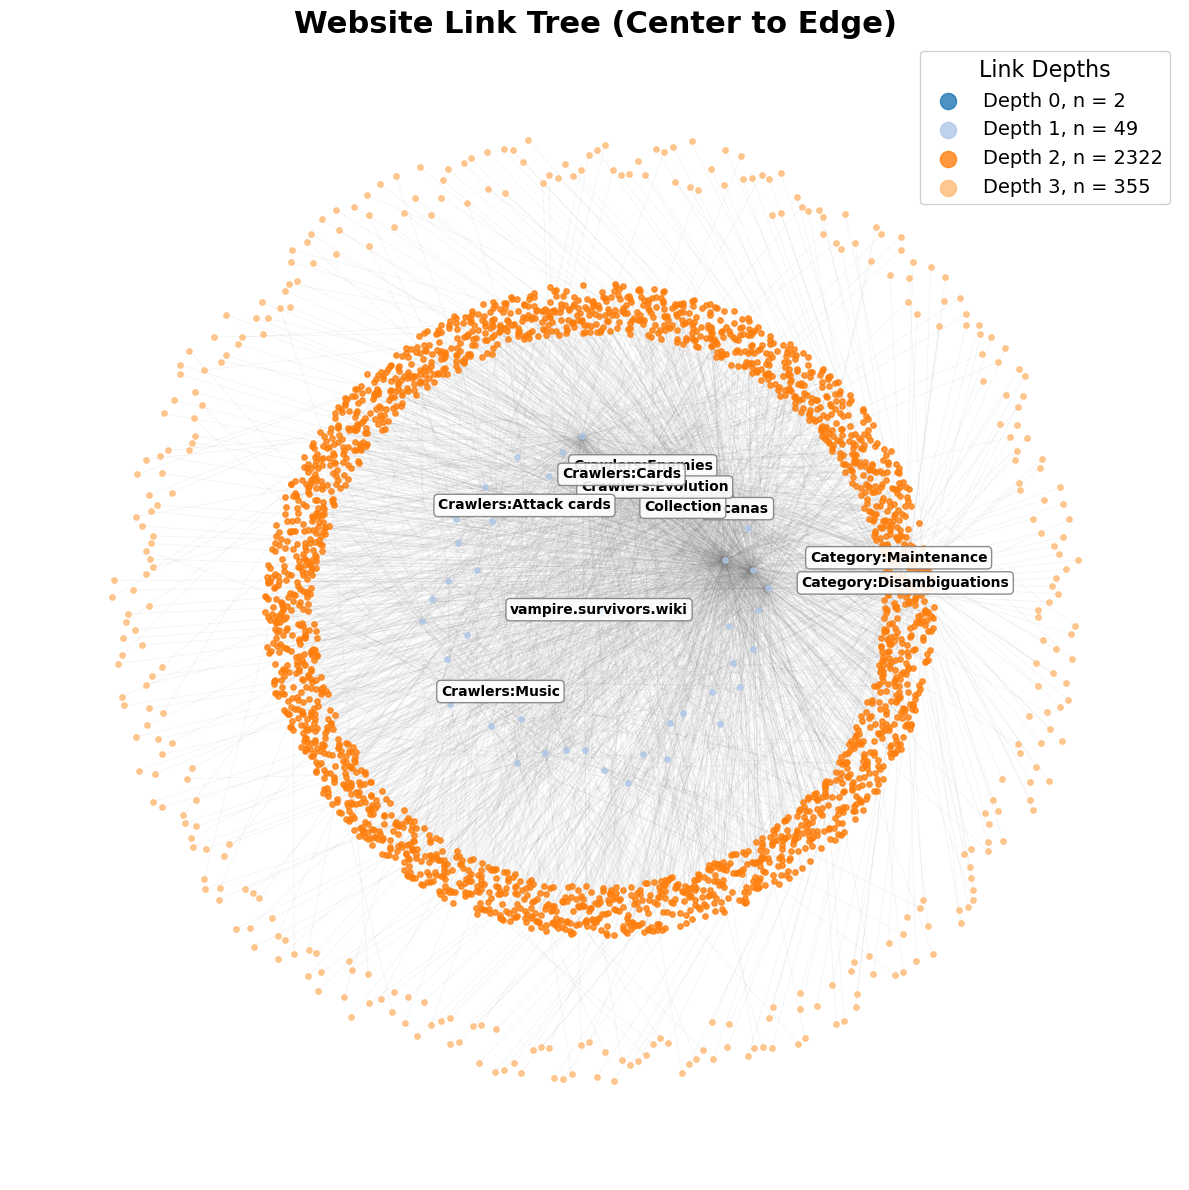

In [71]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import math
import random



G = nx.DiGraph()

for _, row in df.iterrows():
    site = row['site']
    parent = row['parent']
    distance = row['distance']
    

    G.add_node(site, distance=distance)
    
    if pd.notna(parent):
        if parent not in G:
            G.add_node(parent, distance=max(0, distance - 1))
        
        G.add_edge(parent, site)

out_degrees = dict(G.out_degree())
top_n = 15
most_relevant_nodes = sorted(out_degrees, key=out_degrees.get, reverse=True)[5:top_n]

labels = {}
for node in most_relevant_nodes:
    short_name = str(node).rstrip('/').split('/')[-1]
    labels[node] = short_name.replace('_', ' ')

pos = {}

nodes_by_depth = {}
for node, data in G.nodes(data=True):
    d = data.get('distance', 0)
    if d not in nodes_by_depth:
        nodes_by_depth[d] = []
    nodes_by_depth[d].append(node)

for d, nodes in nodes_by_depth.items():
    if d == 0:
        for node in nodes:
            pos[node] = (0, 0) 
    else:
        base_radius = d * 15  
        angle_step = (2 * math.pi) / len(nodes)
        
        for i, node in enumerate(nodes):
            angle = i * angle_step
            radius = base_radius + random.uniform(-2.5, 2.5)
            
            x = radius * math.cos(angle)
            y = radius * math.sin(angle)
            pos[node] = (x, y)

plt.figure(figsize=(12, 12)) 

nx.draw_networkx_edges(G, pos, alpha=0.1, width=0.5, edge_color='gray', arrows=False)

cmap = plt.colormaps.get_cmap('tab20')

sorted_depths = sorted(nodes_by_depth.keys())

for d in sorted_depths:
    nodes = nodes_by_depth[d]
    color = [cmap(d % 20)] 
    
    nx.draw_networkx_nodes(G, pos, 
                           nodelist=nodes, 
                           node_size=15, 
                           node_color=color, 
                           alpha=0.8, 
                           label=f'Depth {int(d)}, n = {len(nodes)}')


nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight='bold', font_color='black',
                        bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3', alpha=0.9))


plt.legend(title='Link Depths', loc='upper right', fontsize=14, title_fontsize=16, markerscale=3, framealpha=0.9)

plt.title('Website Link Tree (Center to Edge)', fontsize=22, fontweight='bold')
plt.axis('off')
plt.tight_layout()

plt.savefig('radial_link_tree.png', dpi=150, bbox_inches='tight')
print("Visualization saved as 'radial_link_tree.png'")

plt.show()

Visualization saved as 'radial_link_tree.png'


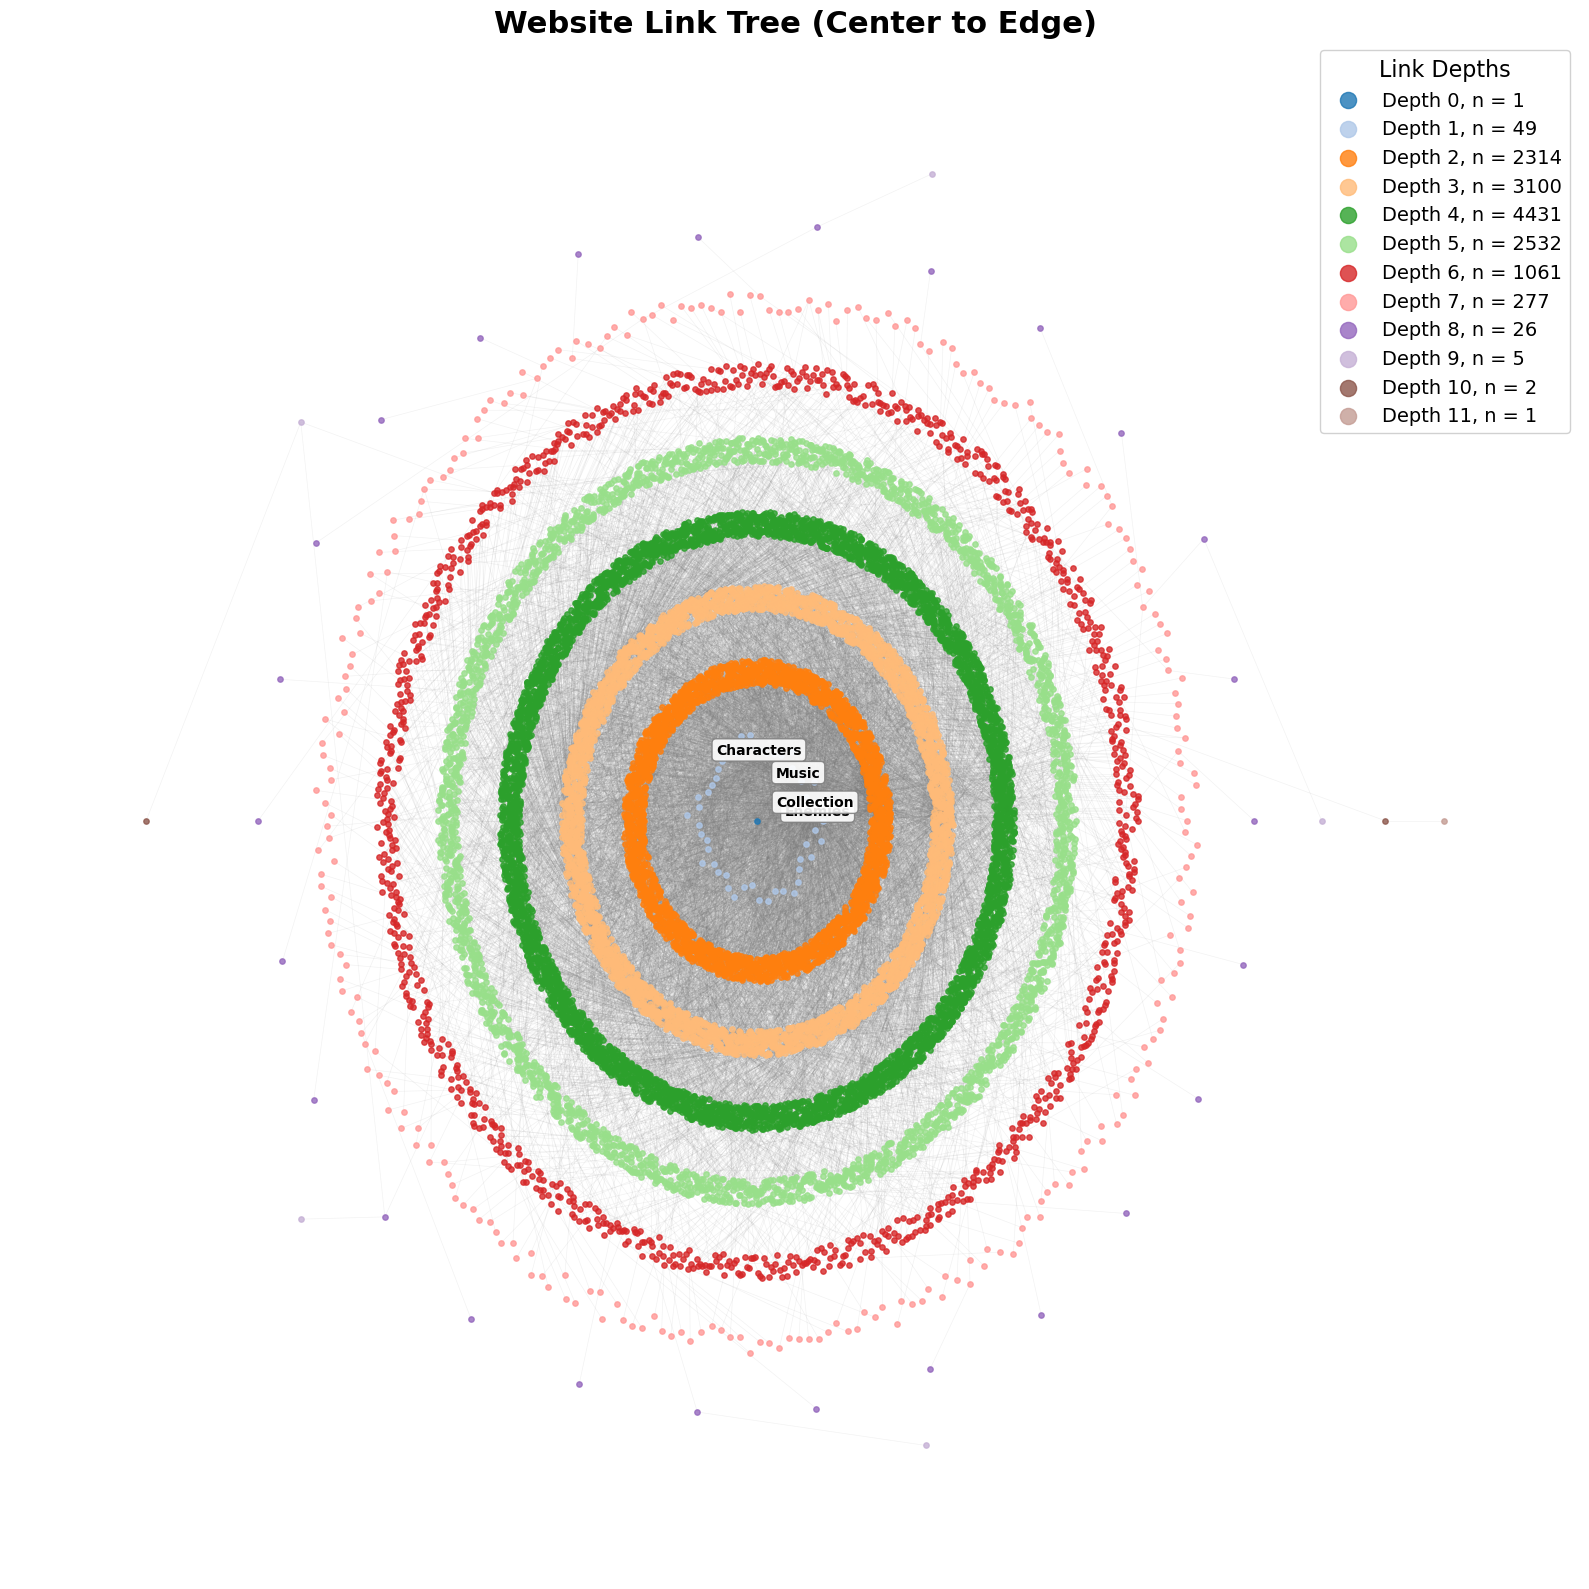

In [69]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import math
import random



G = nx.DiGraph()

for _, row in df.iterrows():
    site = row['site']
    parent = row['parent']
    distance = row['distance']
    

    G.add_node(site, distance=distance)
    
    if pd.notna(parent):
        if parent == "root":
            continue
        if parent not in G:
            G.add_node(parent, distance=max(0, distance - 1))
        
        G.add_edge(parent, site)

out_degrees = dict(G.out_degree())
top_n = 4
most_relevant_nodes = sorted(out_degrees, key=out_degrees.get, reverse=True)[:top_n]

labels = {}
for node in most_relevant_nodes:
    short_name = str(node).rstrip('/').split('/')[-1]
    labels[node] = short_name.replace('_', ' ')

pos = {}

nodes_by_depth = {}
for node, data in G.nodes(data=True):
    d = data.get('distance', 0)
    if d not in nodes_by_depth:
        nodes_by_depth[d] = []
    nodes_by_depth[d].append(node)

for d, nodes in nodes_by_depth.items():
    if d == 0:
        for node in nodes:
            pos[node] = (0, 0) 
    else:
        base_radius = d * 15  
        angle_step = (2 * math.pi) / len(nodes)
        
        for i, node in enumerate(nodes):
            angle = i * angle_step
            radius = base_radius + random.uniform(-2.5, 2.5)
            
            x = radius * math.cos(angle)
            y = radius * math.sin(angle)
            pos[node] = (x, y)

plt.figure(figsize=(16, 16)) 

nx.draw_networkx_edges(G, pos, alpha=0.1, width=0.5, edge_color='gray', arrows=False)

cmap = plt.colormaps.get_cmap('tab20')

sorted_depths = sorted(nodes_by_depth.keys())

for d in sorted_depths:
    nodes = nodes_by_depth[d]
    color = [cmap(d % 20)] 
    
    nx.draw_networkx_nodes(G, pos, 
                           nodelist=nodes, 
                           node_size=15, 
                           node_color=color, 
                           alpha=0.8, 
                           label=f'Depth {int(d)}, n = {len(nodes)}')


nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight='bold', font_color='black',
                        bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3', alpha=0.9))


plt.legend(title='Link Depths', loc='upper right', fontsize=14, title_fontsize=16, markerscale=3, framealpha=0.9)

plt.title('Website Link Tree (Center to Edge)', fontsize=22, fontweight='bold')
plt.axis('off')
plt.tight_layout()

plt.savefig('radial_link_tree_big.png', dpi=250, bbox_inches='tight')
print("Visualization saved as 'radial_link_tree.png'")

plt.show()

## Vampire Survivors

In [2]:
vampires = pd.read_csv("vampire_survivors_without_delays.txt")

In [3]:
vampires

,sites_scraped,number_of_threads,time,adjusted_time
0,2583,5,5.971810,5.971810
1,2580,5,5.943320,5.943320
2,2584,5,6.013850,6.013850
3,2582,5,6.367860,6.367860
4,2544,3,11.366800,11.366800
5,2667,3,9.106480,9.106480
6,2545,3,10.529200,10.529200
7,2667,3,9.501500,9.501500
8,2663,2,20.264100,20.264100
9,2796,2,20.987200,20.987200


In [8]:

average_for_num = {}
std_for_num = {}
average_sites_for_num = {}
std_sites_for_num = {}

for num in set(vampires["number_of_threads"]):
    average_for_num[num] = np.mean(vampires[vampires["number_of_threads"] == num]["time"])
    std_for_num[num] = np.std(vampires[vampires["number_of_threads"] == num]["time"])
    average_sites_for_num[num] = np.mean(vampires[vampires["number_of_threads"] == num]["sites_scraped"])
    std_sites_for_num[num] = np.std(vampires[vampires["number_of_threads"] == num]["sites_scraped"])

In [5]:
average_for_num

{1: np.float64(67.2458),
 2: np.float64(19.693325),
 3: np.float64(10.125995),
 5: np.float64(6.07421),
 10: np.float64(2.397515),
 20: np.float64(1.10339),
 30: np.float64(0.76308875)}

In [6]:
std_for_num

{1: np.float64(7.668258681408708),
 2: np.float64(1.1889137697390004),
 3: np.float64(0.8848129972344438),
 5: np.float64(0.17138524163416197),
 10: np.float64(0.019102382704783122),
 20: np.float64(0.05020708366356282),
 30: np.float64(0.017151283281069647)}

In [12]:
for i in set(vampires["number_of_threads"]):
    print(i)
    print(average_for_num[i])
    print(std_for_num[i])
    print(average_sites_for_num[i])
    print(std_sites_for_num[i])
    print(average_sites_for_num[i]/average_for_num[i]/i)
    print("")

1
67.2458
7.668258681408708
3074.25
65.41167709209114
45.71660981057553

2
19.693325
1.1889137697390004
2692.0
64.13657302974646
68.3480316300066

3
10.125995
0.8848129972344438
2605.75
61.251020399663545
85.77757873012315

5
6.07421
0.17138524163416197
2582.25
1.479019945774904
85.0234022202064

10
2.397515
0.019102382704783122
2740.0
77.4047802141444
114.2849992596501

20
1.10339
0.05020708366356282
2553.25
103.98888161721906
115.70025104450829

30
0.76308875
0.017151283281069647
2760.5
81.98932857390649
120.58448858886554

